In [1]:
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn -q
!pip install 'kagglehub[pandas-datasets]' -q

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import re
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download('vishakhdapat/imdb-movie-reviews')
print('Downloaded to:', path)
files = os.listdir(path)
print('Files in dataset:', files)

csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print('\nFirst 5 records:')
print(df.head())
print('\nShape  :', df.shape)
print('Columns:', df.columns.tolist())

Downloaded to: /Users/shivamsalunke/.cache/kagglehub/datasets/vishakhdapat/imdb-movie-reviews/versions/1
Files in dataset: ['IMDB Dataset.csv']

First 5 records:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Shape  : (50000, 2)
Columns: ['review', 'sentiment']


Columns: ['review', 'sentiment']
Shape  : (50000, 2)

Sample:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive

Label Distribution:
label
1    25000
0    25000
Name: count, dtype: int64

Label Distribution (%):
label
1    50.0
0    50.0
Name: proportion, dtype: float64


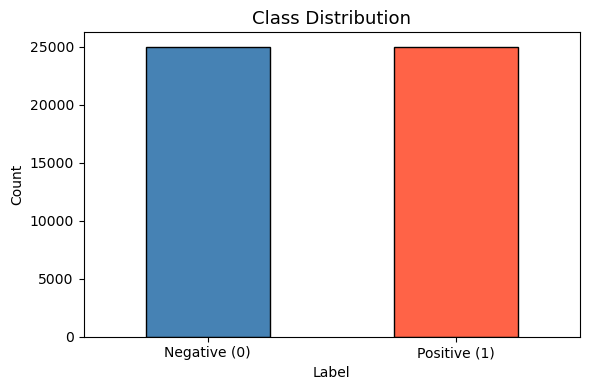

In [4]:
print('Columns:', df.columns.tolist())
print('Shape  :', df.shape)
print('\nSample:')
print(df.head(3))
df.columns = df.columns.str.lower().str.strip()
if 'sentiment' in df.columns:
    df['label'] = df['sentiment'].str.lower().str.strip().map({'positive': 1, 'negative': 0})
    df['text']  = df['review']
elif 'label' not in df.columns:
    raise ValueError(f'Unexpected columns: {df.columns.tolist()}')

df = df[['text', 'label']].dropna().reset_index(drop=True)

print('\nLabel Distribution:')
print(df['label'].value_counts())
print('\nLabel Distribution (%):')
print(df['label'].value_counts(normalize=True).round(4) * 100)

fig, ax = plt.subplots(figsize=(6, 4))
df['label'].value_counts().plot(
    kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black'
)
ax.set_title('Class Distribution', fontsize=13)
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_xticklabels(['Negative (0)', 'Positive (1)'], rotation=0)
plt.tight_layout()
plt.show()

Review Length Statistics (word count):
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


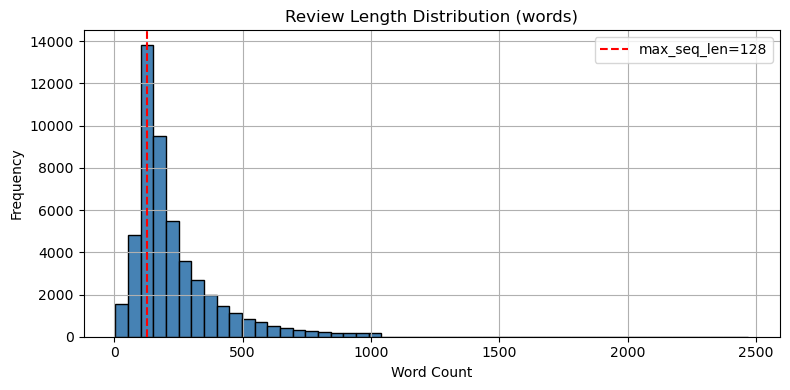

Reviews under 128 words: 26.5%


In [5]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
print('Review Length Statistics (word count):')
print(df['word_count'].describe())

plt.figure(figsize=(8, 4))
df['word_count'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Review Length Distribution (words)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.axvline(128, color='red', linestyle='--', label='max_seq_len=128')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Reviews under 128 words: {(df['word_count'] <= 128).mean():.1%}")

In [6]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)              
    text = re.sub(r'http\S+|www\.\S+', '', text)    
    text = text.lower()                              
    text = re.sub(r'[^a-zA-Z0-9\s!?.,\'\"\-]', '', text)  
    text = re.sub(r'\s+', ' ', text).strip()         
    return text

df['text'] = df['text'].apply(clean_text)
before = len(df)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Rows before cleaning: {before}, after: {len(df)}')

print('\nSample cleaned reviews:')
for i in [0, 1]:
    print(f'\n[Row {i} | Label={df["label"].iloc[i]}]')
    print(' ', df['text'].iloc[i][:200])


Rows before cleaning: 50000, after: 50000

Sample cleaned reviews:

[Row 0 | Label=1]
  one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me. the first thing that struck me about oz was i

[Row 1 | Label=1]
  a wonderful little production. the filming technique is very unassuming- very old-time-bbc fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. the actors


In [7]:

TRAIN_SUBSET = 5000
VAL_SUBSET   = 1000
TEST_SUBSET  = 1000
train_val_df, test_split = train_test_split(
    df, test_size=TEST_SUBSET / len(df),
    stratify=df['label'], random_state=42
)

train_split, val_split = train_test_split(
    train_val_df,
    test_size=VAL_SUBSET / (TRAIN_SUBSET + VAL_SUBSET),
    stratify=train_val_df['label'], random_state=42
)

if len(train_split) > TRAIN_SUBSET:
    train_split, _ = train_test_split(
        train_split, train_size=TRAIN_SUBSET,
        stratify=train_split['label'], random_state=42
    )

train_text   = train_split['text'].reset_index(drop=True)
train_labels = train_split['label'].reset_index(drop=True)

val_text     = val_split['text'].reset_index(drop=True)
val_labels   = val_split['label'].reset_index(drop=True)

test_text    = test_split['text'].reset_index(drop=True)
test_labels  = test_split['label'].reset_index(drop=True)

print(f'Train size : {len(train_text)}')
print(f'Val size   : {len(val_text)}')
print(f'Test size  : {len(test_text)}')
print('\nTrain label distribution:')
print(pd.Series(train_labels).value_counts())

Train size : 5000
Val size   : 8167
Test size  : 1000

Train label distribution:
label
1    2500
0    2500
Name: count, dtype: int64


In [8]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
MAX_SEQ_LEN = 128

def tokenize_data(texts, max_len=MAX_SEQ_LEN):
    return tokenizer(
        texts.tolist(),
        max_length=max_len,
        padding='max_length',
        truncation=True,         
        return_tensors='pt'
    )

print('Tokenizing train set...')
tokens_train = tokenize_data(train_text)
print('Tokenizing val set...')
tokens_val   = tokenize_data(val_text)
print('Tokenizing test set...')
tokens_test  = tokenize_data(test_text)

print('\nTokenization complete.')
print('Train input_ids shape :', tokens_train['input_ids'].shape)

sample_tokens = tokenizer.convert_ids_to_tokens(tokens_train['input_ids'][0][:20])
print('\nSample tokens (first 20):', sample_tokens)

Tokenizing train set...
Tokenizing val set...
Tokenizing test set...

Tokenization complete.
Train input_ids shape : torch.Size([5000, 128])

Sample tokens (first 20): ['[CLS]', 'think', 'pierce', 'bros', '##nan', 'and', 'you', 'think', 'su', '##ave', ',', 'da', '##pper', ',', 'intelligent', 'james', 'bond', '.', 'in', 'this']


In [9]:
train_seq  = tokens_train['input_ids'].clone().detach()
train_mask = tokens_train['attention_mask'].clone().detach()
train_y    = torch.tensor(train_labels.tolist())

val_seq    = tokens_val['input_ids'].clone().detach()
val_mask   = tokens_val['attention_mask'].clone().detach()
val_y      = torch.tensor(val_labels.tolist())

test_seq   = tokens_test['input_ids'].clone().detach()
test_mask  = tokens_test['attention_mask'].clone().detach()
test_y     = torch.tensor(test_labels.tolist())

print('Tensors created.')

Tensors created.


In [10]:
BATCH_SIZE = 16   

train_data   = TensorDataset(train_seq, train_mask, train_y)
val_data     = TensorDataset(val_seq,   val_mask,   val_y)
test_data    = TensorDataset(test_seq,  test_mask,  test_y)

train_loader = DataLoader(train_data, sampler=RandomSampler(train_data),    batch_size=BATCH_SIZE)
val_loader   = DataLoader(val_data,   sampler=SequentialSampler(val_data),  batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_data,  sampler=SequentialSampler(test_data), batch_size=BATCH_SIZE)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 313
Val batches   : 511
Test batches  : 63


In [11]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn):
    """Run one training epoch. Returns avg loss and all predictions."""
    model.train()
    total_loss = 0
    all_preds  = []

    for step, batch in enumerate(loader):
        if step % 50 == 0 and step > 0:
            print(f'    Batch {step:>4} / {len(loader)}')

        sent_id, mask, labels = [b.to(device) for b in batch]

        model.zero_grad()
        outputs = model(sent_id, attention_mask=mask)
        logits  = outputs.logits

        loss = loss_fn(logits, labels)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        all_preds.extend(preds)

    return total_loss / len(loader), np.array(all_preds)


def evaluate_epoch(model, loader, loss_fn):
    """Evaluate model. Returns avg loss and all predictions."""
    model.eval()
    total_loss = 0
    all_preds  = []

    with torch.no_grad():
        for batch in loader:
            sent_id, mask, labels = [b.to(device) for b in batch]
            outputs = model(sent_id, attention_mask=mask)
            logits  = outputs.logits

            loss = loss_fn(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
            all_preds.extend(preds)

    return total_loss / len(loader), np.array(all_preds)


def print_metrics(y_true, y_pred, label='Test'):
    """Print Accuracy, Precision, Recall, F1, and full classification report."""
    print(f'\n=== {label} Metrics ===')
    print(f'  Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision : {precision_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'  Recall    : {recall_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'  F1 Score  : {f1_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'\nDetailed Classification Report:')
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    """Plot a labeled confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(title, fontsize=13)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


def plot_loss_curves(train_losses, val_losses, title='Loss Curves'):
    """Plot training vs validation loss per epoch."""
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(train_losses)+1), train_losses, 'b-o', label='Train Loss')
    plt.plot(range(1, len(val_losses)+1),   val_losses,   'r-o', label='Val Loss')
    plt.title(title, fontsize=13)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def run_experiment(freeze_mode, epochs=3, lr=2e-5):
    print(f'\n{"="*60}')
    print(f'  Experiment: freeze_mode={freeze_mode!r} | epochs={epochs} | lr={lr}')
    print(f'{"="*60}')

    model = AutoModelForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=2
    ).to(device)

    for param in model.bert.parameters():
        param.requires_grad = False

    if freeze_mode == 'last2':
        for layer in model.bert.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True
        for param in model.bert.pooler.parameters():
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Trainable params : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

    loss_fn = nn.CrossEntropyLoss()
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    total_steps = len(train_loader) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state    = None

    for epoch in range(epochs):
        print(f'\n  Epoch {epoch+1}/{epochs}')
        tr_loss, _ = train_epoch(model, train_loader, optimizer, scheduler, loss_fn)
        vl_loss, _ = evaluate_epoch(model, val_loader, loss_fn)

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)

        print(f'  Train Loss: {tr_loss:.4f}  |  Val Loss: {vl_loss:.4f}')

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    _, test_preds = evaluate_epoch(model, test_loader, loss_fn)

    return test_preds, train_losses, val_losses

print('Helper functions defined.')

Helper functions defined.


In [12]:
preds_exp1, tr_losses_exp1, vl_losses_exp1 = run_experiment(
    freeze_mode='all',
    epochs=3,
    lr=2e-5
)


  Experiment: freeze_mode='all' | epochs=3 | lr=2e-05


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params : 1,538 / 109,483,778 (0.0%)

  Epoch 1/3
    Batch   50 / 313
    Batch  100 / 313
    Batch  150 / 313
    Batch  200 / 313
    Batch  250 / 313
    Batch  300 / 313
  Train Loss: 0.7005  |  Val Loss: 0.6910

  Epoch 2/3
    Batch   50 / 313
    Batch  100 / 313
    Batch  150 / 313
    Batch  200 / 313
    Batch  250 / 313
    Batch  300 / 313
  Train Loss: 0.6915  |  Val Loss: 0.6892

  Epoch 3/3
    Batch   50 / 313
    Batch  100 / 313
    Batch  150 / 313
    Batch  200 / 313
    Batch  250 / 313
    Batch  300 / 313
  Train Loss: 0.6868  |  Val Loss: 0.6877



=== Experiment 1 (Frozen BERT) — Test Metrics ===
  Accuracy  : 0.5440
  Precision : 0.5727
  Recall    : 0.5440
  F1 Score  : 0.4941

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.23      0.34       500
    Positive       0.53      0.86      0.65       500

    accuracy                           0.54      1000
   macro avg       0.57      0.54      0.49      1000
weighted avg       0.57      0.54      0.49      1000



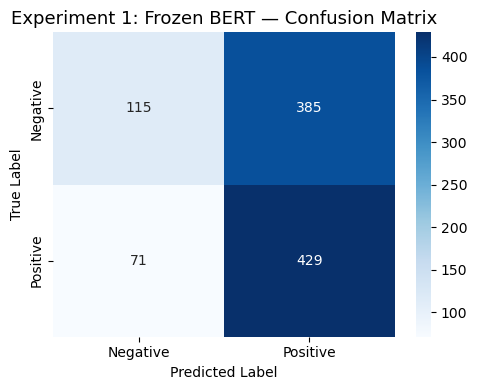

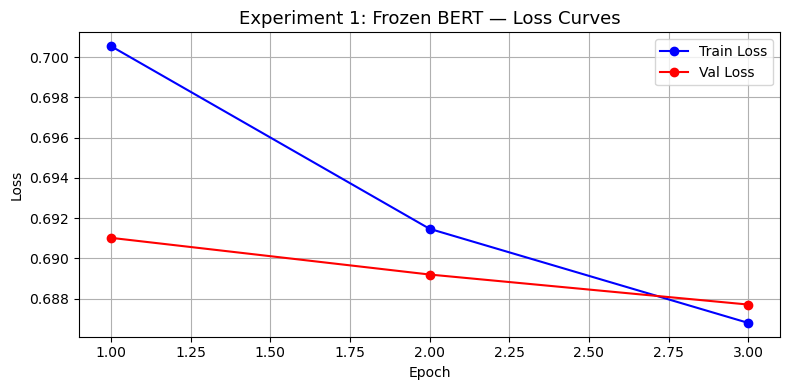

In [13]:
y_true = test_y.numpy()

print_metrics(y_true, preds_exp1, label='Experiment 1 (Frozen BERT) — Test')
plot_confusion_matrix(y_true, preds_exp1, title='Experiment 1: Frozen BERT — Confusion Matrix')
plot_loss_curves(tr_losses_exp1, vl_losses_exp1, title='Experiment 1: Frozen BERT — Loss Curves')

In [14]:
preds_exp2, tr_losses_exp2, vl_losses_exp2 = run_experiment(
    freeze_mode='last2',
    epochs=3,
    lr=2e-5
)


  Experiment: freeze_mode='last2' | epochs=3 | lr=2e-05


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params : 14,767,874 / 109,483,778 (13.5%)

  Epoch 1/3
    Batch   50 / 313
    Batch  100 / 313
    Batch  150 / 313
    Batch  200 / 313
    Batch  250 / 313
    Batch  300 / 313
  Train Loss: 0.5080  |  Val Loss: 0.3543

  Epoch 2/3
    Batch   50 / 313
    Batch  100 / 313
    Batch  150 / 313
    Batch  200 / 313
    Batch  250 / 313
    Batch  300 / 313
  Train Loss: 0.3439  |  Val Loss: 0.3259

  Epoch 3/3
    Batch   50 / 313
    Batch  100 / 313
    Batch  150 / 313
    Batch  200 / 313
    Batch  250 / 313
    Batch  300 / 313
  Train Loss: 0.3041  |  Val Loss: 0.3324



=== Experiment 2 (Last 2 Layers) — Test Metrics ===
  Accuracy  : 0.8590
  Precision : 0.8604
  Recall    : 0.8590
  F1 Score  : 0.8589

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.89      0.86       500
    Positive       0.88      0.83      0.85       500

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



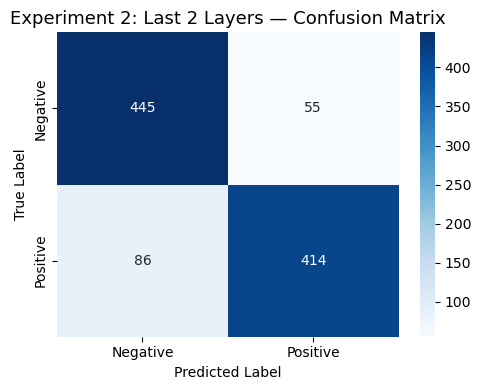

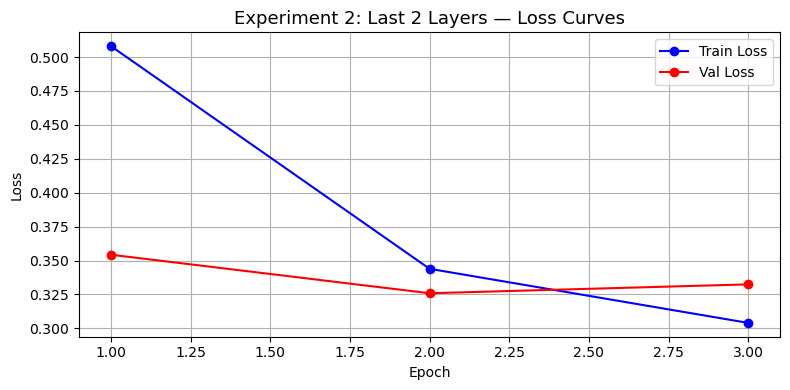

In [15]:
print_metrics(y_true, preds_exp2, label='Experiment 2 (Last 2 Layers) — Test')
plot_confusion_matrix(y_true, preds_exp2, title='Experiment 2: Last 2 Layers — Confusion Matrix')
plot_loss_curves(tr_losses_exp2, vl_losses_exp2, title='Experiment 2: Last 2 Layers — Loss Curves')

In [16]:
def get_metrics_dict(y_true, y_pred, name):
    return {
        'Experiment' : name,
        'Accuracy'   : round(accuracy_score(y_true, y_pred), 4),
        'Precision'  : round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall'     : round(recall_score(y_true, y_pred, average='weighted'), 4),
        'F1 Score'   : round(f1_score(y_true, y_pred, average='weighted'), 4),
    }

comparison_df = pd.DataFrame([
    get_metrics_dict(y_true, preds_exp1, 'Exp 1: Frozen BERT'),
    get_metrics_dict(y_true, preds_exp2, 'Exp 2: Last 2 Layers'),
]).set_index('Experiment')

print('\n=== Experiment Comparison ===')
print(comparison_df.to_string())
comparison_df


=== Experiment Comparison ===
                      Accuracy  Precision  Recall  F1 Score
Experiment                                                 
Exp 1: Frozen BERT       0.544     0.5727   0.544    0.4941
Exp 2: Last 2 Layers     0.859     0.8604   0.859    0.8589


,Accuracy,Precision,Recall,F1 Score
Experiment,,,,
Exp 1: Frozen BERT,0.544,0.5727,0.544,0.4941
Exp 2: Last 2 Layers,0.859,0.8604,0.859,0.8589


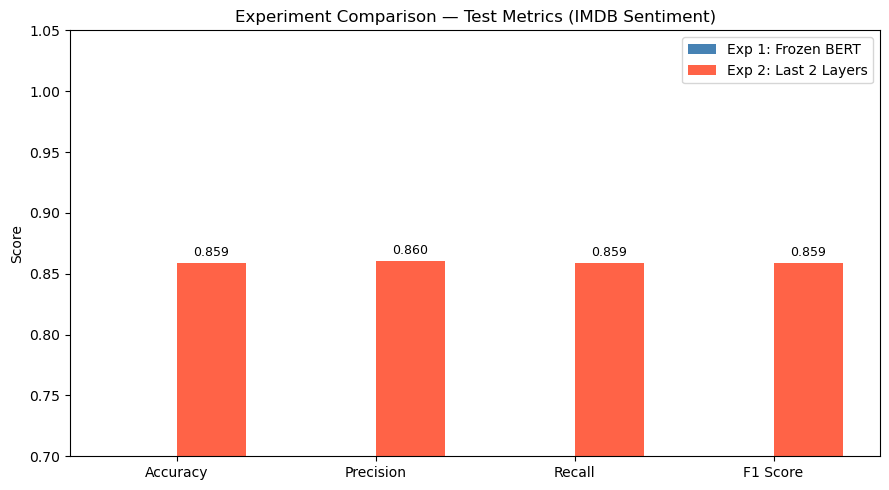

In [17]:

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, comparison_df.loc['Exp 1: Frozen BERT'][metrics],   width, label='Exp 1: Frozen BERT',   color='steelblue')
bars2 = ax.bar(x + width/2, comparison_df.loc['Exp 2: Last 2 Layers'][metrics], width, label='Exp 2: Last 2 Layers', color='tomato')

ax.set_ylim(0.7, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Experiment Comparison — Test Metrics (IMDB Sentiment)')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

In [18]:
sample_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat.",
    "Terrible film. Complete waste of time. The plot made no sense and the acting was wooden.",
    "A masterpiece of cinema. Beautifully shot with outstanding performances from the entire cast.",
    "I fell asleep halfway through. Boring, predictable, and just not worth watching.",
    "One of the best films I have seen this year. Highly recommended to everyone!",
    "The special effects were okay but the story was dull and the characters were forgettable.",
]

def predict_reviews(model, reviews, tokenizer, max_len=MAX_SEQ_LEN):
    """Predict sentiment for a list of movie reviews."""
    model.eval()
    cleaned = [clean_text(r) for r in reviews]
    tokens  = tokenizer(
        cleaned,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids = tokens['input_ids'].to(device)
    attn_mask = tokens['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attn_mask)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        preds   = np.argmax(probs, axis=1)

    print('Demo Predictions (Experiment 2 — Last 2 Layers Model):')
    print('-' * 70)
    for review, pred, prob in zip(reviews, preds, probs):
        label = 'POSITIVE 😊' if pred == 1 else 'NEGATIVE 😞'
        print(f'[{label}] ({prob[pred]:.2%})  →  {review[:65]}...')
